Maximo, Minimo, Promedio, Varianza, Covarianza, Persentiles y Cuartiles

In [8]:
from src.database import get_database

db = get_database()

In [2]:
for key in db.mexico_city_covid_data.find_one().keys():
    type_ = type(db.mexico_city_covid_data.find_one()[key])
    print(f"{key}: {type_}")

_id: <class 'bson.objectid.ObjectId'>
ID_REGISTRO: <class 'str'>
ASMA: <class 'str'>
CARDIOVASCULAR: <class 'str'>
CLASIFICACION_FINAL_COVID: <class 'str'>
CLASIFICACION_FINAL_FLU: <class 'str'>
DIABETES: <class 'str'>
EDAD: <class 'int'>
EMBARAZO: <class 'str'>
ENTIDAD_NAC: <class 'str'>
ENTIDAD_RES: <class 'str'>
ENTIDAD_UM: <class 'str'>
EPOC: <class 'str'>
FECHA_ACTUALIZACION: <class 'str'>
FECHA_DEF: <class 'str'>
FECHA_INGRESO: <class 'str'>
FECHA_SINTOMAS: <class 'str'>
HABLA_LENGUA_INDIG: <class 'str'>
HIPERTENSION: <class 'str'>
INDIGENA: <class 'str'>
INMUSUPR: <class 'str'>
INTUBADO: <class 'str'>
MIGRANTE: <class 'str'>
MUNICIPIO_RES: <class 'str'>
NACIONALIDAD: <class 'str'>
NEUMONIA: <class 'str'>
OBESIDAD: <class 'str'>
ORIGEN: <class 'str'>
OTRA_COM: <class 'str'>
OTRO_CASO: <class 'str'>
PAIS_NACIONALIDAD: <class 'str'>
PAIS_ORIGEN: <class 'str'>
RENAL_CRONICA: <class 'str'>
RESULTADO_ANTIGENO: <class 'str'>
RESULTADO_PCR: <class 'str'>
RESULTADO_PCR_COINFECCION: <clas

In [3]:
import polars as pl 
import matplotlib.pyplot as plt

projection = { "_id": 0, "EDAD": 1, "HIPERTENSION": 1 }

cursor = db.mexico_city_covid_data.find({}, projection)

df = pl.from_dicts(cursor)

print(len(df))

7299605


In [21]:
print(len(df))

7299605


In this case we are using a lot of ram  
11489.4 avail Mem 

after 

11489.4 avail Mem 

In [7]:
resume = df.select([
    pl.col("EDAD").max().alias("Edad Maxima"),
    pl.col("EDAD").min().alias("Edad Minima"), 
    pl.col("EDAD").mean().alias("Edad Promedio")
])

edad_max = resume["Edad Maxima"][0]
edad_min = resume["Edad Minima"][0]
edad_prom = resume["Edad Promedio"][0]

print(f"Edad Maxima: {edad_max}")
print(f"Edad Minima: {edad_min}")
print(f"Edad Promedio: {edad_prom}")

Edad Maxima: 164
Edad Minima: 0
Edad Promedio: 38.87510324188774


In [17]:
oldest = db.mexico_city_covid_data.find({"EDAD": {"$gt": 122}})

for old in oldest:
    print(old)


count = db.mexico_city_covid_data.count_documents({"EDAD": {"$gt": 122}})
print(count)

{'_id': ObjectId('6a0e1c39448a0b8f404bd32f'), 'ID_REGISTRO': 'm1e5dae', 'ASMA': '2', 'CARDIOVASCULAR': '2', 'CLASIFICACION_FINAL_COVID': '7', 'CLASIFICACION_FINAL_FLU': '6', 'DIABETES': '2', 'EDAD': 147, 'EMBARAZO': '97', 'ENTIDAD_NAC': '09', 'ENTIDAD_RES': '15', 'ENTIDAD_UM': '15', 'EPOC': '2', 'FECHA_ACTUALIZACION': '2022-08-09', 'FECHA_DEF': '9999-99-99', 'FECHA_INGRESO': '2021-10-17', 'FECHA_SINTOMAS': '2021-10-14', 'HABLA_LENGUA_INDIG': '99', 'HIPERTENSION': '2', 'INDIGENA': '99', 'INMUSUPR': '2', 'INTUBADO': '97', 'MIGRANTE': '99', 'MUNICIPIO_RES': '999', 'NACIONALIDAD': '1', 'NEUMONIA': '99', 'OBESIDAD': '2', 'ORIGEN': '2', 'OTRA_COM': '98', 'OTRO_CASO': '99', 'PAIS_NACIONALIDAD': 'México', 'PAIS_ORIGEN': '97', 'RENAL_CRONICA': '2', 'RESULTADO_ANTIGENO': '2', 'RESULTADO_PCR': '97', 'RESULTADO_PCR_COINFECCION': '997', 'SECTOR': '12', 'SEXO': '2', 'TABAQUISMO': '2', 'TIPO_PACIENTE': '1', 'TOMA_MUESTRA_ANTIGENO': '1', 'TOMA_MUESTRA_LAB': '2', 'UCI': '97', 'YEAR_ORIGIN': 2021}
{'_id

In [18]:

count = db.mexico_city_covid_data.count_documents({"EDAD": {"$gt": 100}})
print(count)

count = db.mexico_city_covid_data.count_documents({"EDAD": {"$gt": 90}})
print(count)

6084
16479


In [19]:
# Analizar el estado de salud de los mayores de 100 años
centenarios = db.mexico_city_covid_data.find({"EDAD": {"$gt": 100}})

for p in centenarios:
    print(f"ID: {p['ID_REGISTRO']} | Edad: {p['EDAD']} | Paciente: {p['TIPO_PACIENTE']} (1=Amb, 2=Hosp) | Neumonía: {p['NEUMONIA']} (1=Sí) | Fallecido: {p['FECHA_DEF']}")

ID: 1def59 | Edad: 119 | Paciente: 1 (1=Amb, 2=Hosp) | Neumonía: 1 (1=Sí) | Fallecido: 2020-05-01
ID: 0293c7 | Edad: 104 | Paciente: 1 (1=Amb, 2=Hosp) | Neumonía: 2 (1=Sí) | Fallecido: 9999-99-99
ID: 17b23c | Edad: 102 | Paciente: 1 (1=Amb, 2=Hosp) | Neumonía: 2 (1=Sí) | Fallecido: 9999-99-99
ID: 10d03e | Edad: 106 | Paciente: 2 (1=Amb, 2=Hosp) | Neumonía: 2 (1=Sí) | Fallecido: 9999-99-99
ID: 035f7a | Edad: 103 | Paciente: 2 (1=Amb, 2=Hosp) | Neumonía: 1 (1=Sí) | Fallecido: 2020-04-22
ID: 145b04 | Edad: 101 | Paciente: 2 (1=Amb, 2=Hosp) | Neumonía: 1 (1=Sí) | Fallecido: 9999-99-99
ID: 08a5b5 | Edad: 115 | Paciente: 2 (1=Amb, 2=Hosp) | Neumonía: 1 (1=Sí) | Fallecido: 9999-99-99
ID: 05194d | Edad: 106 | Paciente: 1 (1=Amb, 2=Hosp) | Neumonía: 2 (1=Sí) | Fallecido: 9999-99-99
ID: 05dbf0 | Edad: 101 | Paciente: 1 (1=Amb, 2=Hosp) | Neumonía: 1 (1=Sí) | Fallecido: 9999-99-99
ID: 14794e | Edad: 102 | Paciente: 1 (1=Amb, 2=Hosp) | Neumonía: 2 (1=Sí) | Fallecido: 9999-99-99
ID: 0e3f7c | Edad: 1

In [20]:
edades_a_revisar = [90, 95, 100, 105, 110, 122]
for e in edades_a_revisar:
    c = db.mexico_city_covid_data.count_documents({"EDAD": {"$gt": e}})
    print(f"Pacientes mayores a {e} años: {c}")

Pacientes mayores a 90 años: 16479
Pacientes mayores a 95 años: 8541
Pacientes mayores a 100 años: 6084
Pacientes mayores a 105 años: 5150
Pacientes mayores a 110 años: 4752
Pacientes mayores a 122 años: 11


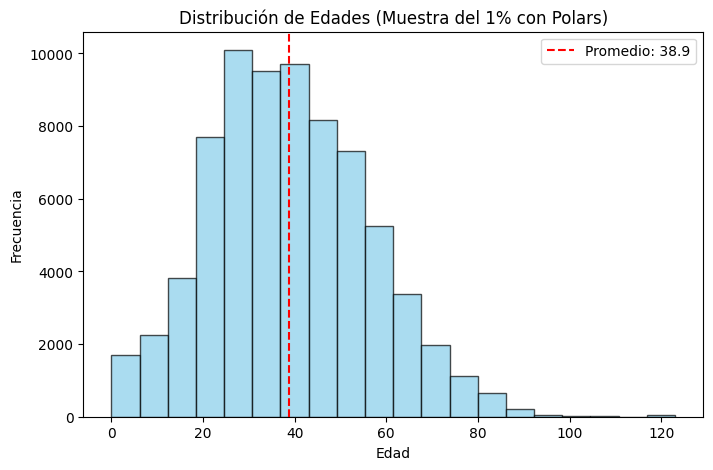

In [22]:
import matplotlib.pyplot as plt

df_muestra = df.select(pl.col("EDAD")).sample(fraction=0.01, with_replacement=False)
plt.figure(figsize=(8, 5))
plt.hist(df_muestra["EDAD"], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(edad_prom, color='red', linestyle='--', label=f'Promedio: {edad_prom:.1f}')
plt.title('Distribución de Edades (Muestra del 1% con Polars)')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

In [24]:
resumen_dispersion = df.select([
    pl.col("EDAD").var().alias("Varianza_Edad"),
    pl.cov("EDAD", "HIPERTENSION").alias("Covarianza_Edad_Hipertension")
])

print(f"Varianza: {resumen_dispersion['Varianza_Edad'][0]:.2f}")
print(f"Covarianza: {resumen_dispersion['Covarianza_Edad_Hipertension'][0]:.2f}")

Varianza: 300.19
Covarianza: 4.92


In [26]:
cuartiles = df.select([
    pl.col("EDAD").quantile(0.25).alias("Q1"),
    pl.col("EDAD").quantile(0.50).alias("Mediana"),
    pl.col("EDAD").quantile(0.75).alias("Q3"),
    pl.col("EDAD").quantile(0.90).alias("Percentil_90")
])

print(f"Q1: {cuartiles['Q1'][0]} | Mediana: {cuartiles['Mediana'][0]} | Q3: {cuartiles['Q3'][0]}")

Q1: 26.0 | Mediana: 38.0 | Q3: 51.0


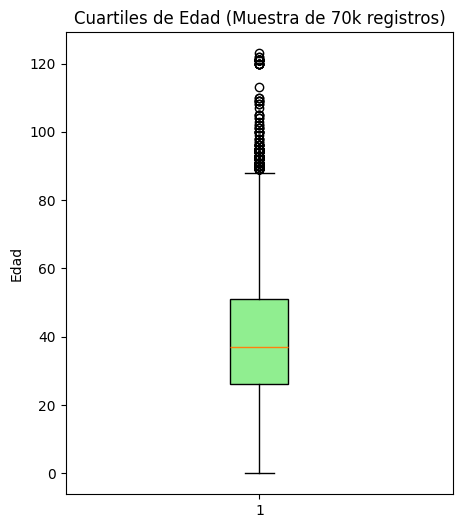

In [27]:
plt.figure(figsize=(5, 6))
plt.boxplot(df_muestra["EDAD"], patch_artist=True, boxprops=dict(facecolor='lightgreen'))
plt.title('Cuartiles de Edad (Muestra de 70k registros)')
plt.ylabel('Edad')
plt.show()

In [ ]:
#review

from pymongo import MongoClient
import polars as pl
import pyarrow.parquet as pq

client = MongoClient("mongodb://localhost:27017")

collection = client.db.mexico_city_covid_data

cursor = collection.find({}, batch_size=100_000)

writer = None
batch = []

for doc in cursor:
    doc["_id"] = str(doc["_id"])
    batch.append(doc)

    if len(batch) >= 100_000:

        df = pl.DataFrame(batch)

        table = df.to_arrow()

        if writer is None:
            writer = pq.ParquetWriter(
                "mexico_city_covid_data.parquet",
                table.schema
            )

        writer.write_table(table)

        batch = []

# último batch
if batch:
    df = pl.DataFrame(batch)
    table = df.to_arrow()

    if writer is None:
        writer = pq.ParquetWriter(
            "mexico_city_covid_data.parquet",
            table.schema
        )

    writer.write_table(table)

writer.close()